In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('max_columns',24)


In [9]:
df = pd.read_csv("Kopi af Copy of MASTER DOKUMENT 2025 - Sheet1.csv")

"""Step 1: Data Understanding"""

df.shape


(224, 24)

In [10]:
df.head()

,,NAVN,GENRE,cover,original,PRIS,AFREGNING,PUBLIKUM,Antal musikere,LYD,TIER,EVENT,IG POST,INDHOLD PRESS,GFX,KONTRAKT SENDT,MODTAGET,4 STORIES,2 REELS,I AFTEN REEL,@dropdown,Unnamed: 21,Unnamed: 22,#NAME?
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,MARTS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,01-03-24,Karl Meyer,Pop,NaN,1.0,100,12025,70.0,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,02-03-24,Stakkels Jim,Cover,1.0,NaN,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df.columns

Index([' ', 'NAVN', 'GENRE', 'cover', 'original', 'PRIS', 'AFREGNING',
       'PUBLIKUM', 'Antal musikere', 'LYD', 'TIER ', 'EVENT', 'IG POST',
       'INDHOLD PRESS', 'GFX', 'KONTRAKT SENDT', 'MODTAGET', '4 STORIES',
       '2 REELS', 'I AFTEN REEL', '@dropdown', 'Unnamed: 21', 'Unnamed: 22',
       '#NAME?'],
      dtype='object')

In [12]:
df.dtypes

                   object
NAVN               object
GENRE              object
cover             float64
original          float64
PRIS               object
AFREGNING          object
PUBLIKUM          float64
Antal musikere     object
LYD                object
TIER               object
EVENT              object
IG POST            object
INDHOLD PRESS      object
GFX                object
KONTRAKT SENDT     object
MODTAGET           object
4 STORIES          object
2 REELS            object
I AFTEN REEL       object
@dropdown         float64
Unnamed: 21       float64
Unnamed: 22        object
#NAME?            float64
dtype: object

In [13]:
df.describe()

,cover,original,PUBLIKUM,@dropdown,Unnamed: 21,#NAME?
count,31.0,94.0,74.000000,0.0,0.0,0.0
mean,1.0,1.0,72.054054,NaN,NaN,NaN
std,0.0,0.0,39.665689,NaN,NaN,NaN
min,1.0,1.0,6.000000,NaN,NaN,NaN
25%,1.0,1.0,39.000000,NaN,NaN,NaN
50%,1.0,1.0,68.000000,NaN,NaN,NaN
75%,1.0,1.0,94.250000,NaN,NaN,NaN
max,1.0,1.0,175.000000,NaN,NaN,NaN


Step 2: Data Prep

In [14]:
import functions as fct

In [15]:
df = fct.make_num(df,'PRIS','Andet')

In [16]:
df = fct.make_num(df,'AFREGNING','Andet')

In [17]:
def tier():
    for i in range(len(df))[1:-1]:
        if pd.isna(df.loc[i,'TIER ']):
            pass
        else: 
            tier = df.loc[i,'TIER ']
            df.loc[i,'TIER '] = tier[-1]
    df['TIER ']=df['TIER '].astype(dtype=float)



In [18]:
tier()
df['TIER '].unique()

array([nan,  2.,  3.,  1.])

In [19]:
df[['PRIS','AFREGNING']]=df[['PRIS','AFREGNING']].astype(dtype=float)

In [20]:
#df['Andet'].unique()
df['NAVN'].duplicated()

0      False
1       True
2      False
3      False
4       True
       ...  
219     True
220     True
221    False
222     True
223     True
Name: NAVN, Length: 224, dtype: bool

In [21]:
df = df[[' ', 
    'NAVN', 
    'GENRE', 'cover', 'original', 'PRIS', 'AFREGNING',
       'PUBLIKUM', 
       #'Antal musikere', 'LYD', 
       'TIER ', 'EVENT', 'IG POST',
       #'INDHOLD PRESS', 'GFX', 'KONTRAKT SENDT', 'MODTAGET', '4 STORIES',
       #'2 REELS', 'I AFTEN REEL', '@dropdown', 'Unnamed: 21', 'Unnamed: 22',
       #'#NAME?', 'Andet'
       ]].copy()

In [22]:
df.shape

(224, 11)

In [23]:
df.dtypes

              object
NAVN          object
GENRE         object
cover        float64
original     float64
PRIS         float64
AFREGNING    float64
PUBLIKUM     float64
TIER         float64
EVENT         object
IG POST       object
dtype: object

In [24]:
import re
def dato():
    for i in range(len(df))[1:-1]:
        if pd.isna(df.loc[i,' '])==False and re.search("[0-9]",df.loc[i,' '])==None:
            df.loc[i,' ']=np.nan
        else: 
            pass
    df[' '] = pd.to_datetime(df[' '])


In [25]:
dato()
df[' ']

0            NaT
1            NaT
2     2024-01-03
3     2024-02-03
4            NaT
         ...    
219   2025-02-22
220          NaT
221   2025-02-27
222   2025-02-28
223   2025-01-25
Name:  , Length: 224, dtype: datetime64[ns]

In [26]:
df.columns

Index([' ', 'NAVN', 'GENRE', 'cover', 'original', 'PRIS', 'AFREGNING',
       'PUBLIKUM', 'TIER ', 'EVENT', 'IG POST'],
      dtype='object')

In [27]:
df = df.rename(columns={' ':'Dato', 
                   'NAVN':'Navn',
                   'GENRE': 'Genre',
                     'cover':'Cover',
                     'original':'OG',
                     'PRIS':'Pris',
                     'AFREGNING':'Afr',
                     'PUBLIKUM':'Pub',
                     'TIER ':'Tier',
                     'EVENT':'Event', 
                     'IG POST':'IG'})

In [28]:
df.shape

(224, 11)

In [29]:
df.isna().sum()

Dato      62
Navn      74
Genre    107
Cover    193
OG       130
Pris     102
Afr      120
Pub      150
Tier     178
Event    191
IG       193
dtype: int64

In [30]:
#df.drop(df.loc[df.duplicated()],axis=0)
df = df.dropna(axis=0,how='all')
df.loc[df.duplicated()]

,Dato,Navn,Genre,Cover,OG,Pris,Afr,Pub,Tier,Event,IG


In [31]:
df.drop(df[pd.isna(df['Pub'])].index,axis=0,inplace=True)
df

,Dato,Navn,Genre,Cover,OG,Pris,Afr,Pub,Tier,Event,IG
2,2024-01-03,Karl Meyer,Pop,NaN,1.0,100.0,12025.0,70.0,NaN,NaN,NaN
6,2024-08-03,Maya´s Call,Indie Rock,NaN,1.0,80.0,5000.0,134.0,NaN,NaN,NaN
9,2024-03-14,James Walker + Daisy Chute,NaN,NaN,1.0,80.0,3500.0,33.0,NaN,NaN,NaN
10,2024-03-15,AMILA,Pop/Soul,NaN,1.0,100.0,6500.0,90.0,NaN,NaN,NaN
11,2024-03-16,Indigo Hotstep,NaN,NaN,1.0,75.0,NaN,121.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
125,2024-09-28,Los Fuegos,Latin,NaN,1.0,100.0,1.0,128.0,3.0,x,x
128,2024-03-10,The Reptones,Indie/folk,NaN,1.0,75.0,4810.0,23.0,2.0,x,NaN
129,2024-04-10,Røde Far,NaN,NaN,1.0,75.0,9620.0,163.0,3.0,NaN,NaN
130,2024-05-10,Elektrisk Ål,Latin,NaN,1.0,100.0,9620.0,81.0,3.0,x,x


In [32]:
#df.query('Dato == "2025-02-22"')
df.reset_index(drop=True,inplace=True)
df

,Dato,Navn,Genre,Cover,OG,Pris,Afr,Pub,Tier,Event,IG
0,2024-01-03,Karl Meyer,Pop,NaN,1.0,100.0,12025.0,70.0,NaN,NaN,NaN
1,2024-08-03,Maya´s Call,Indie Rock,NaN,1.0,80.0,5000.0,134.0,NaN,NaN,NaN
2,2024-03-14,James Walker + Daisy Chute,NaN,NaN,1.0,80.0,3500.0,33.0,NaN,NaN,NaN
3,2024-03-15,AMILA,Pop/Soul,NaN,1.0,100.0,6500.0,90.0,NaN,NaN,NaN
4,2024-03-16,Indigo Hotstep,NaN,NaN,1.0,75.0,NaN,121.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
69,2024-09-28,Los Fuegos,Latin,NaN,1.0,100.0,1.0,128.0,3.0,x,x
70,2024-03-10,The Reptones,Indie/folk,NaN,1.0,75.0,4810.0,23.0,2.0,x,NaN
71,2024-04-10,Røde Far,NaN,NaN,1.0,75.0,9620.0,163.0,3.0,NaN,NaN
72,2024-05-10,Elektrisk Ål,Latin,NaN,1.0,100.0,9620.0,81.0,3.0,x,x


In [33]:
#Ændrer x'erne til 1-taller, så jeg kan lave binær undersøgelse af dem :)
for i in range(len(df))[1:-1]:
    if df.loc[i,'IG']=='x':
        df.loc[i,'IG'] = 1.0
    else:
        pass
for i in range(len(df))[1:-1]:
    if df.loc[i,'Event']=='x':
        df.loc[i,'Event'] = 1.0
    else:
        pass


In [34]:
#df['IG'].unique()
#df['Event'].unique()

In [35]:
df['IG']=pd.to_numeric(df['IG'])
df['Event']=pd.to_numeric(df['Event'])
df.dtypes

Dato     datetime64[ns]
Navn             object
Genre            object
Cover           float64
OG              float64
Pris            float64
Afr             float64
Pub             float64
Tier            float64
Event           float64
IG              float64
dtype: object

In [36]:
df.describe()

,Cover,OG,Pris,Afr,Pub,Tier,Event,IG
count,14.0,57.0,71.000000,59.000000,74.000000,19.000000,12.0,20.0
mean,1.0,1.0,101.492958,5850.762712,72.054054,2.263158,1.0,1.0
std,0.0,0.0,31.829399,4810.781825,39.665689,0.871914,0.0,0.0
min,1.0,1.0,1.000000,0.000000,6.000000,1.000000,1.0,1.0
25%,1.0,1.0,80.000000,1.000000,39.000000,1.500000,1.0,1.0
50%,1.0,1.0,100.000000,6500.000000,68.000000,3.000000,1.0,1.0
75%,1.0,1.0,110.000000,9620.000000,94.250000,3.000000,1.0,1.0
max,1.0,1.0,200.000000,14430.000000,175.000000,3.000000,1.0,1.0


In [37]:
df.duplicated(subset=['Navn','Dato'])

0     False
1     False
2     False
3     False
4     False
      ...  
69    False
70    False
71    False
72    False
73    False
Length: 74, dtype: bool

In [38]:
df[['Pris','Afr']] = df[['Pris','Afr']].fillna(1.0)

In [39]:
df[['Event','IG','Cover','OG']] = df[['Event','IG','Cover','OG']].fillna(0.0)

In [40]:
df['Genre'] = df['Genre'].fillna(2)

In [41]:
"""Til sidst laver jeg her nogle ekstra kolonner, som er brugbare at se på."""
df['Ratio']=df['Afr'].div(df['Pub'])
df

,Dato,Navn,Genre,Cover,OG,Pris,Afr,Pub,Tier,Event,IG,Ratio
0,2024-01-03,Karl Meyer,Pop,0.0,1.0,100.0,12025.0,70.0,NaN,0.0,0.0,171.785714
1,2024-08-03,Maya´s Call,Indie Rock,0.0,1.0,80.0,5000.0,134.0,NaN,0.0,0.0,37.313433
2,2024-03-14,James Walker + Daisy Chute,2,0.0,1.0,80.0,3500.0,33.0,NaN,0.0,0.0,106.060606
3,2024-03-15,AMILA,Pop/Soul,0.0,1.0,100.0,6500.0,90.0,NaN,0.0,0.0,72.222222
4,2024-03-16,Indigo Hotstep,2,0.0,1.0,75.0,1.0,121.0,NaN,0.0,0.0,0.008264
...,...,...,...,...,...,...,...,...,...,...,...,...
69,2024-09-28,Los Fuegos,Latin,0.0,1.0,100.0,1.0,128.0,3.0,1.0,1.0,0.007812
70,2024-03-10,The Reptones,Indie/folk,0.0,1.0,75.0,4810.0,23.0,2.0,1.0,0.0,209.130435
71,2024-04-10,Røde Far,2,0.0,1.0,75.0,9620.0,163.0,3.0,0.0,0.0,59.018405
72,2024-05-10,Elektrisk Ål,Latin,0.0,1.0,100.0,9620.0,81.0,3.0,1.0,1.0,118.765432


In [42]:
df['A/P']=df['Afr'].div(df['Pris'])
df

,Dato,Navn,Genre,Cover,OG,Pris,Afr,Pub,Tier,Event,IG,Ratio,A/P
0,2024-01-03,Karl Meyer,Pop,0.0,1.0,100.0,12025.0,70.0,NaN,0.0,0.0,171.785714,120.250000
1,2024-08-03,Maya´s Call,Indie Rock,0.0,1.0,80.0,5000.0,134.0,NaN,0.0,0.0,37.313433,62.500000
2,2024-03-14,James Walker + Daisy Chute,2,0.0,1.0,80.0,3500.0,33.0,NaN,0.0,0.0,106.060606,43.750000
3,2024-03-15,AMILA,Pop/Soul,0.0,1.0,100.0,6500.0,90.0,NaN,0.0,0.0,72.222222,65.000000
4,2024-03-16,Indigo Hotstep,2,0.0,1.0,75.0,1.0,121.0,NaN,0.0,0.0,0.008264,0.013333
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,2024-09-28,Los Fuegos,Latin,0.0,1.0,100.0,1.0,128.0,3.0,1.0,1.0,0.007812,0.010000
70,2024-03-10,The Reptones,Indie/folk,0.0,1.0,75.0,4810.0,23.0,2.0,1.0,0.0,209.130435,64.133333
71,2024-04-10,Røde Far,2,0.0,1.0,75.0,9620.0,163.0,3.0,0.0,0.0,59.018405,128.266667
72,2024-05-10,Elektrisk Ål,Latin,0.0,1.0,100.0,9620.0,81.0,3.0,1.0,1.0,118.765432,96.200000


Step 3: Feature Understanding

In [43]:
df['Pub'].value_counts() #her er det ikke så brugbart...men sejt :)

90.0     3
38.0     3
40.0     3
39.0     3
88.0     2
73.0     2
33.0     2
57.0     2
31.0     2
67.0     2
80.0     2
37.0     1
70.0     1
83.0     1
134.0    1
26.0     1
92.0     1
106.0    1
72.0     1
14.0     1
123.0    1
175.0    1
125.0    1
42.0     1
102.0    1
121.0    1
128.0    1
58.0     1
17.0     1
47.0     1
95.0     1
6.0      1
100.0    1
23.0     1
132.0    1
86.0     1
109.0    1
63.0     1
69.0     1
21.0     1
119.0    1
43.0     1
51.0     1
161.0    1
113.0    1
120.0    1
59.0     1
74.0     1
49.0     1
45.0     1
130.0    1
76.0     1
152.0    1
55.0     1
163.0    1
15.0     1
36.0     1
81.0     1
35.0     1
Name: Pub, dtype: int64

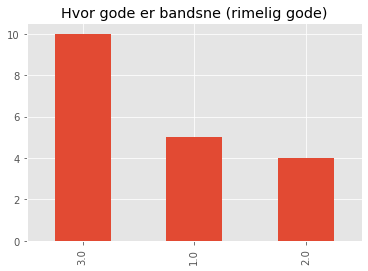

In [44]:
"""Bare for øvelses skyld gør jeg som Rob Mulla her, men det er ikke så informativt"""
ax = df['Tier'].value_counts() \
            .head() \
            .plot(kind='bar', title='Hvor gode er bandsne (rimelig gode)')

Text(0, 0.5, 'Frekvens')

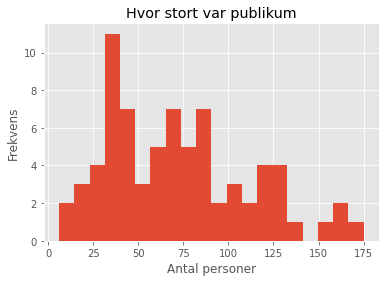

In [45]:
axP = df['Pub'].plot(kind='hist'
                     ,bins=20,
                     title='Hvor stort var publikum')
axP.set_xlabel('Antal personer')
axP.set_ylabel('Frekvens')

Text(0, 0.5, 'Frekvens')

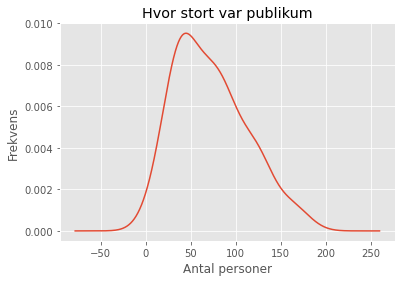

In [46]:
axP = df['Pub'].plot(kind='kde',
                     title='Hvor stort var publikum')
axP.set_xlabel('Antal personer')
axP.set_ylabel('Frekvens')

Step 4: Feature Realtionships

In [47]:
"""Først skal genre-kolonnen ændres, så vi kan sammenligne den med de andre kolonner. """
len(df['Genre'].unique()) #Så der er 42 "forskellige" genrer
genrer = df['Genre'].unique().tolist()
genrer.index('Funk') #Så vi bestemmer simpelthen genren ud fra dens plads i denne liste

25

In [48]:
genrer[25] #Som vi kan se her, kan vi altid tilgå det igen :)

'Funk'

In [49]:
def genre():
    for i in range(len(df))[:-1]:
        df.loc[i,'Genre']=genrer.index(df.loc[i,'Genre'])

In [50]:
genre()
df

,Dato,Navn,Genre,Cover,OG,Pris,Afr,Pub,Tier,Event,IG,Ratio,A/P
0,2024-01-03,Karl Meyer,0,0.0,1.0,100.0,12025.0,70.0,NaN,0.0,0.0,171.785714,120.250000
1,2024-08-03,Maya´s Call,1,0.0,1.0,80.0,5000.0,134.0,NaN,0.0,0.0,37.313433,62.500000
2,2024-03-14,James Walker + Daisy Chute,2,0.0,1.0,80.0,3500.0,33.0,NaN,0.0,0.0,106.060606,43.750000
3,2024-03-15,AMILA,3,0.0,1.0,100.0,6500.0,90.0,NaN,0.0,0.0,72.222222,65.000000
4,2024-03-16,Indigo Hotstep,2,0.0,1.0,75.0,1.0,121.0,NaN,0.0,0.0,0.008264,0.013333
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,2024-09-28,Los Fuegos,36,0.0,1.0,100.0,1.0,128.0,3.0,1.0,1.0,0.007812,0.010000
70,2024-03-10,The Reptones,16,0.0,1.0,75.0,4810.0,23.0,2.0,1.0,0.0,209.130435,64.133333
71,2024-04-10,Røde Far,2,0.0,1.0,75.0,9620.0,163.0,3.0,0.0,0.0,59.018405,128.266667
72,2024-05-10,Elektrisk Ål,36,0.0,1.0,100.0,9620.0,81.0,3.0,1.0,1.0,118.765432,96.200000


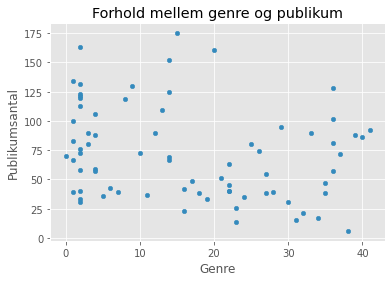

In [51]:
ax = df.plot(kind='scatter',
        x='Genre',
        y='Pub',
        title='Forhold mellem genre og publikum')
ax.set_xlabel('Genre')
ax.set_ylabel('Publikumsantal')
plt.show()

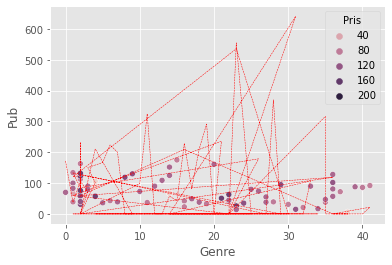

In [52]:
"""Her kan vi se forholdet mellem Afregning og Publikum målt op imod genre, og hvor selve prisen for at komme ind er afmærket med farve. """
ax3 = sns.scatterplot(x='Genre',
                y='Pub',
                hue='Pris',
                data=df)
axA = plt.plot(df['Genre'], #x-værdi
               df['Afr'].div(df['Pub']), #y-værdi
               color='red', 
               linestyle='dashed',linewidth=0.5)
plt.show()

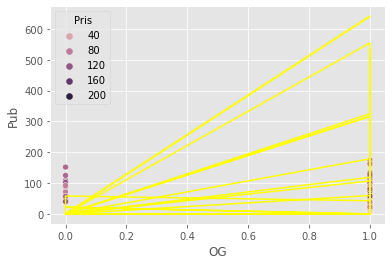

'SKRÆKKELIGT'

In [53]:
"""Her kan vi se forholdet mellem Afregning og Publikum målt op imod hvorvidt musikken er original eller cover. """
ax3 = sns.scatterplot(x='OG',
                y='Pub',
                hue='Pris',
                data=df)
axA = plt.plot(df['OG'],df['Afr'].div(df['Pub']),color='yellow')
plt.show()
"""SKRÆKKELIGT"""

C:\Users\mikke\anaconda3\lib\site-packages\seaborn\distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)
C:\Users\mikke\anaconda3\lib\site-packages\seaborn\distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)
C:\Users\mikke\anaconda3\lib\site-packages\seaborn\distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)
C:\Users\mikke\anaconda3\lib\site-packages\seaborn\distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)
C:\Users\mikke\anaconda3\lib\site-packages\seaborn\distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)
C:\Users\mikke\anaconda3\lib\site-packages\seaborn\distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnin

TypeError: No loop matching the specified signature and casting was found for ufunc add

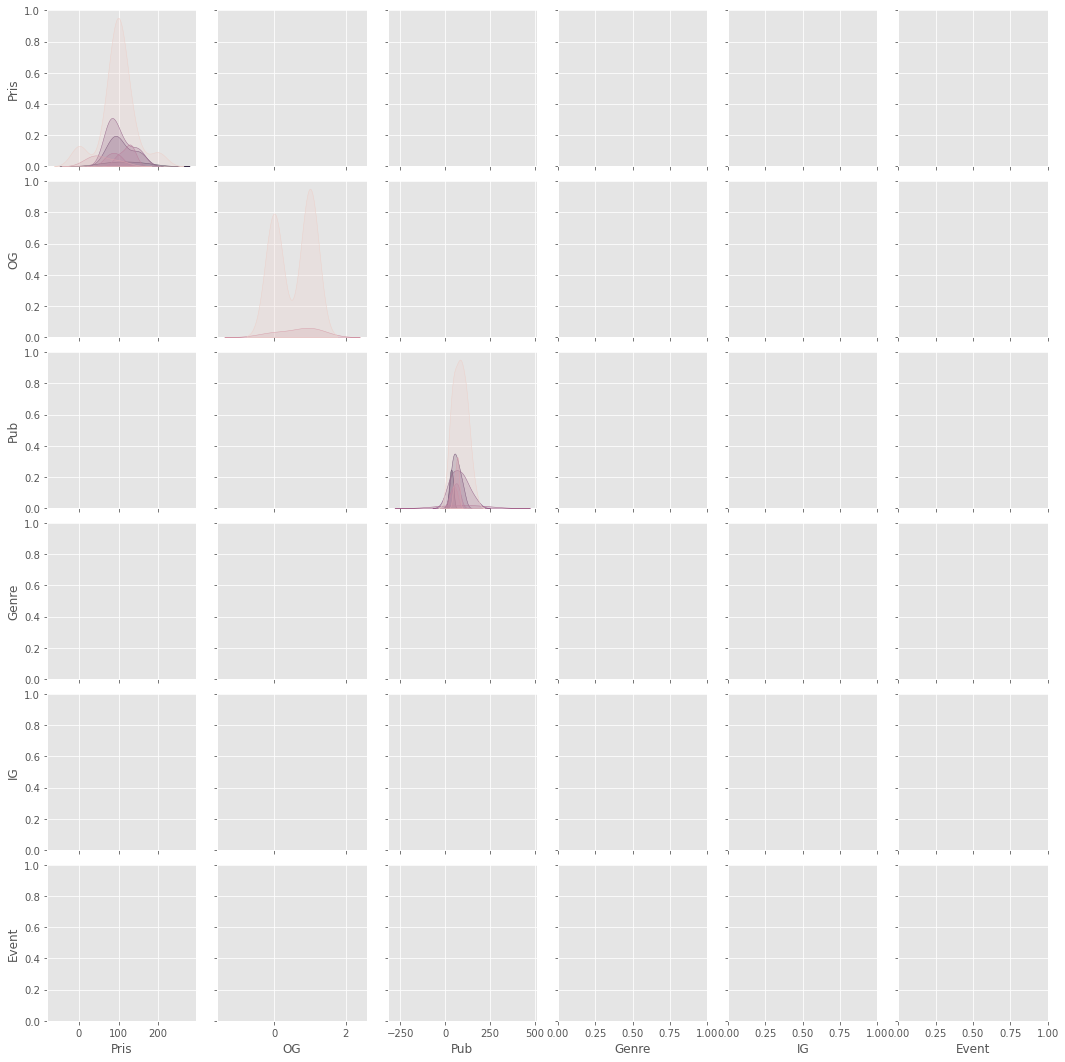

In [54]:
sns.pairplot(data=df, hue='Afr',
             vars=['Pris', 'OG','Pub', 'Genre', 'IG', 'Event']             
             )

In [55]:
df.isna()

,Dato,Navn,Genre,Cover,OG,Pris,Afr,Pub,Tier,Event,IG,Ratio,A/P
0,False,False,False,False,False,False,False,False,True,False,False,False,False
1,False,False,False,False,False,False,False,False,True,False,False,False,False
2,False,False,False,False,False,False,False,False,True,False,False,False,False
3,False,False,False,False,False,False,False,False,True,False,False,False,False
4,False,False,False,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,False,False,False,False,False,False,False,False,False,False,False,False,False
70,False,False,False,False,False,False,False,False,False,False,False,False,False
71,False,False,False,False,False,False,False,False,False,False,False,False,False
72,False,False,False,False,False,False,False,False,False,False,False,False,False


In [62]:
#df_corr = df[['Pris', 'OG','Pub', 'Genre', 'IG', 'Event','Afr','Ratio']].corr() skal være uden ratio, som er afr/pub
df_corr = df[['Pris', 'OG','Pub', 'Genre', 'IG', 'Event','Afr']].corr()
df_corr #et forfærdeligt datasæt

,Pris,OG,Pub,IG,Event,Afr
Pris,1.000000,0.083131,0.087757,-0.060744,-0.167586,0.157897
OG,0.083131,1.000000,-0.059591,0.115348,-0.282659,0.483931
Pub,0.087757,-0.059591,1.000000,-0.070349,-0.041549,-0.162775
IG,-0.060744,0.115348,-0.070349,1.000000,0.145026,0.162472
Event,-0.167586,-0.282659,-0.041549,0.145026,1.000000,-0.207363
Afr,0.157897,0.483931,-0.162775,0.162472,-0.207363,1.000000


<AxesSubplot:>

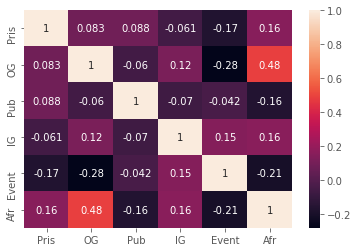

In [63]:
sns.heatmap(df_corr,annot=True)

Step 5: Ask a question about the data

In [64]:
"""Hvilket spørgsmål trænger sig mest på? Jeg undrer mig især over forholdet mellem genre, pris, eventopslag og publikum. Afregning er også
vigtig, så vi kan måle, hvor meget musikerne egentlig behøver at koste. Så lad os kigge på 75-kvartilen af publikumsantal. """
df.describe()[['Afr','Pub','Ratio']]

,Afr,Pub,Ratio
count,74.000000,74.000000,74.000000
mean,4665.000000,72.054054,100.587193
std,4898.391492,39.665689,139.885263
min,0.000000,6.000000,0.000000
25%,1.000000,39.000000,0.012800
50%,4000.000000,68.000000,50.414079
75%,9620.000000,94.250000,162.578125
max,14430.000000,175.000000,641.333333


In [65]:
t_k_k = df[df['Pub']>=94] #tre kvart kvartil


In [66]:
t_k_k.describe() 
"""Her kan vi se, at den højeste udgift pr. næse faktisk er lavere i den øverste kvartil end i hele datasættet"""

'Her kan vi se, at den højeste udgift pr. næse faktisk er lavere i den øverste kvartil end i hele datasættet'

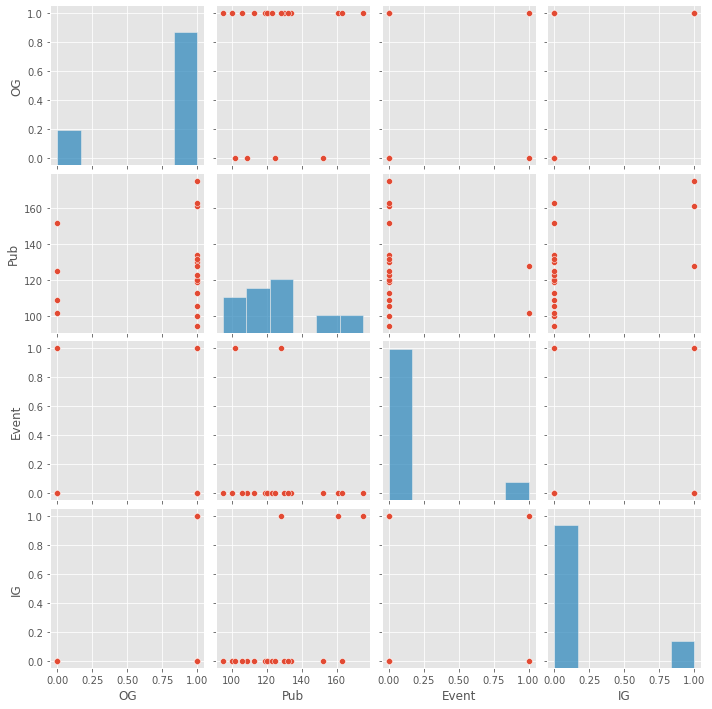

In [67]:
sns.pairplot(t_k_k, vars=['OG','Pub','Event','IG'])